# BLIP-2（Bootstrapping Language-Image Pre-training with Frozen Image Encoders and Large Language Models）模型

> **论文**：*BLIP-2: Bootstrapping Language-Image Pre-training with Frozen Image Encoders and Large Language Models*  
> **核心创新**：引入轻量级 **Q-Former**（Querying Transformer）桥接冻结的视觉编码器和冻结的大语言模型（LLM），以极少参数实现多模态理解与生成。  
> **三大组件**：冻结的大型 ViT（图像编码器）→ 可训练 Q-Former（视觉-语言对齐）→ 冻结的大语言模型（文本生成）

## 一、BLIP-2 图像描述生成（Image Captioning）

### 1.1 基础推理流程

加载 `Salesforce/blip2-opt-2.7b` 模型，输入一张图像，观察处理器配置、
模型结构和生成的描述文本，理解 BLIP-2 端到端推理的完整数据流。

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Blip2Processor:
- image_processor: BlipImageProcessorFast {
  "crop_size": null,
  "data_format": "channels_first",
  "default_to_square": true,
  "device": null,
  "do_center_crop": null,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.48145466,
    0.4578275,
    0.40821073
  ],
  "image_processor_type": "BlipImageProcessorFast",
  "image_std": [
    0.26862954,
    0.26130258,
    0.27577711
  ],
  "input_data_format": null,
  "processor_class": "Blip2Processor",
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "return_tensors": null,
  "size": {
    "height": 224,
    "width": 224
  }
}

- tokenizer: GPT2TokenizerFast(name_or_path='Salesforce/blip2-opt-2.7b', vocab_size=50265, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '</s>', 'eos_token': '</s>', 'unk_token': '</s>', 'pad_token': '<pad>'}, clean_up_tokeniza

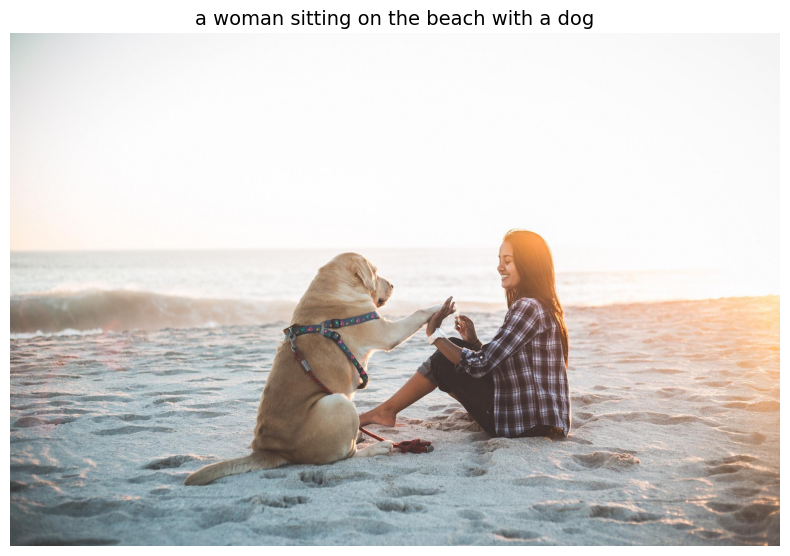

In [2]:
from PIL import Image  # 导入Pillow图像处理库，用于打开和读取图像文件
from transformers import Blip2Processor, Blip2ForConditionalGeneration  # 从HuggingFace导入BLIP-2处理器和条件生成模型
import torch  # 导入PyTorch框架，提供张量计算和GPU加速能力

# 自动检测GPU可用性：有CUDA设备则使用GPU推理，否则使用CPU（注意：BLIP-2体积较大，CPU推理较慢）
device = "cuda" if torch.cuda.is_available() else "cpu"

# 根据设备动态选择数据精度：
# - GPU（CUDA）：使用 float16（半精度），节省约50%显存，CUDA 原生支持所有 float16 算子
# - CPU：必须使用 float32（单精度），CPU 的 LayerNorm 等算子不支持 float16，否则报 RuntimeError
torch_dtype = torch.float16 if device == "cuda" else torch.float32

# 加载 BLIP-2 处理器：包含 BlipImageProcessor（图像预处理）和 GPT2TokenizerFast（文本分词）
processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b",cache_dir="./model_cache/blip2",use_fast=True)
# 加载 BLIP-2 条件生成模型（blip2-opt-2.7b = ViT-G/14 + Q-Former + OPT-2.7B）
# torch_dtype 根据设备自动选择：GPU 用 float16（~11GB显存），CPU 用 float32（~22GB内存）
model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b", torch_dtype=torch_dtype, cache_dir="./model_cache/blip2"
)

# 同时指定 device 和 dtype，确保所有参数（含 query_tokens、layernorm 等）
# 都被完整迁移到目标设备和精度，避免 from_pretrained 未完整转换导致的类型不匹配
model.to(device=device, dtype=torch_dtype)

image = Image.open('dog.jpg')  # 加载本地图像文件（支持 jpg/png 等 Pillow 支持的格式）
print(processor)  # 打印处理器详细配置：图像预处理参数和分词器信息
print('-'*100)  # 打印分隔线，分隔处理器输出和后续内容

# 使用处理器预处理图像：resize到224×224、归一化、转为张量，同时移至设备并转为对应精度
inputs = processor(images=image, return_tensors="pt").to(device, torch_dtype)
print(inputs['pixel_values'].shape)  # 打印预处理后的图像张量形状，预期为 (1, 3, 224, 224)

# 模型前向生成：图像张量经 ViT → Q-Former → OPT-LLM 三阶段自回归生成描述 token 序列
# generated_ids 形状 (batch_size, gen_len)：
# - dim0 batch_size=1: 本次推理的图像数量（单张图像输入）
# - dim1 gen_len: 自回归生成的 token 总数（由模型的 max_new_tokens 默认值控制上限，含 bos token）
generated_ids = model.generate(**inputs)

# batch_decode 将形状 (batch_size, gen_len) 的 token ID 矩阵批量解码为字符串列表
# skip_special_tokens=True：自动过滤 bos_token（</s>）、pad_token（<pad>）等特殊 token
# [0]：取 batch 中第一条（也是唯一一条）解码结果，类型为 str
# .strip()：去除首尾多余的空白字符，得到干净的描述文本
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
print(generated_text)  # 打印最终生成的图像描述文本

import matplotlib.pyplot as plt  # 导入 matplotlib 绘图库，用于在 notebook 中内联显示图像

# 创建画布，figsize=(8, 6) 表示宽8英寸、高6英寸（约203×152 mm），适合单张图像展示
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(image)  # 将 PIL Image 对象直接渲染到坐标轴上，自动处理 RGB 通道顺序
ax.set_title(generated_text, fontsize=14)  # 将模型生成的描述文本作为图像标题显示，字号14pt
ax.axis('off')  # 关闭坐标轴刻度和边框，避免影响图像视觉效果
plt.tight_layout()  # 自动调整子图边距，防止标题与图像重叠
plt.show()  # 在 notebook 中内联渲染并展示图像

## 二、前向传播 Hook 方式监控 Q-Former 内部特征

本节使用 PyTorch `register_forward_hook` 钩子函数，在 **不修改模型源码** 的情况下，
拦截 Q-Former 第0层的自注意力和交叉注意力的输入形状，验证数据流是否符合预期：
- Q-Former 自注意力输入：`(1, 32, 768)` — 32个可学习 Query Token
- Q-Former 交叉注意力输入：`(1, 32, 768)` — Query Token 作为 Q
- 图像编码器输出（Encoder Hidden States）：`(1, 257, 1408)` — ViT patch 特征

In [1]:
from PIL import Image  # 导入 Pillow 图像处理库；Image 类提供 open/save/resize 等接口，是 Python 图像读取的标准方案
from transformers import Blip2Processor, Blip2ForConditionalGeneration  # Blip2Processor：封装图像预处理器+文本分词器的统一接口；Blip2ForConditionalGeneration：BLIP-2完整三段式模型（ViT→Q-Former→LLM）
import torch  # 导入 PyTorch 深度学习框架；提供 Tensor、自动微分、设备管理、模块钩子等核心功能

# ---- 设备与精度自动选择 ----
# torch.cuda.is_available() 返回 bool：True 表示当前机器有可用的 NVIDIA CUDA GPU
# 赋值结果为字符串 "cuda" 或 "cpu"，后续统一通过此变量控制所有张量/模型的存储位置
device = "cuda" if torch.cuda.is_available() else "cpu"

# torch.float16（半精度，2字节/参数）：仅在 CUDA 上使用，可将显存占用减半；
# torch.float32（单精度，4字节/参数）：CPU 必须使用，因 CPU 的 LayerNorm/Softmax 等算子不支持 float16
# 赋值结果为 torch.dtype 枚举类型，后续在模型加载和数据转换时保持全链路精度一致
torch_dtype = torch.float16 if device == "cuda" else torch.float32

# Image.open() 以懒加载方式打开图像文件，返回 PIL.Image.Image 对象
# 此时图像尚未完全解码到内存，只在后续操作（resize/转Tensor）时才真正读取像素数据
# 返回值类型：PIL.Image.Image，属性包含 size=(width, height)、mode（如"RGB"/"RGBA"）
image = Image.open('dog.jpg')

# f-string 格式化输出，打印当前推理设备（"cuda" 或 "cpu"），便于确认运行环境是否符合预期
print(f"Using device: {device}")

# ---- 打印分隔线，标识第二种监控方式（Forward Hook）的演示入口 ----
print("\n" + "="*60)  # "\n" 换行后打印60个等号，作为视觉分隔
print("Alternative Method: Using Forward Hooks")  # 说明本段演示使用 PyTorch Forward Hook 机制（相对于修改模型源码的侵入式方案）
print("="*60)  # 再次打印分隔线，形成标题框效果

# ---- 加载 BLIP-2 处理器 ----
# Blip2Processor.from_pretrained() 从 HuggingFace Hub 或本地缓存加载处理器配置
# 参数说明：
#   - "Salesforce/blip2-opt-2.7b"：HuggingFace 模型仓库 ID，指定 BLIP-2 配套 OPT-2.7B 解码器的版本
#   - cache_dir：本地缓存目录，首次下载后存储到此路径，避免重复联网下载
#   - use_fast=True：使用 Rust 实现的快速分词器（tokenizers 库），比纯 Python 版本速度快 10-100 倍
# 返回值类型：Blip2Processor 对象，内部封装了两个子组件：
#   1. image_processor（BlipImageProcessorFast）：负责图像 resize→224×224、归一化（减均值/除标准差）
#   2. tokenizer（GPT2TokenizerFast）：负责文本→token ID 的双向转换，词表大小 50265
processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b", cache_dir="./model_cache/blip2", use_fast=True)


def reset_model_and_use_hooks():
    """
    以 Forward Hook 方式在不修改模型源码的前提下监控 Q-Former 内部各关键层的特征形状。

    核心思路：
      - PyTorch 的 register_forward_hook() 允许在任意 nn.Module 上注册回调函数；
        每次该模块完成前向传播时，PyTorch 自动调用钩子并传入 (module, input, output)；
      - 相比直接修改 forward() 源码，Hook 方式具有"零侵入、随时注册/移除"的优点，
        是调试和可视化神经网络中间特征的最佳实践；
      - 本函数在 Q-Former 第0层的自注意力（attention）和交叉注意力（crossattention）上
        各注册一个钩子，分别打印 Query Token 特征维度和 ViT 图像特征维度；
      - 推理结束后在 finally 块中统一移除钩子，确保模型状态干净，不影响后续调用。

    数据流说明（BLIP-2 三阶段）：
      输入图像（224×224×3）
        → ViT（EVA-ViT-G/14，39层，patch_size=14）
        → 图像特征 (1, 257, 1408)  ← crossattention_hook 在此处捕获 encoder_hidden_states
        → Q-Former（12层 BERT-like，32个可学习 Query Token，隐藏维768）
        → 压缩视觉特征 (1, 32, 768)  ← attention_hook 在此处捕获 query 输入
        → 线性投影层（768→2560）
        → OPT-2.7B LLM（自回归生成文本 token）

    Returns:
        None
        所有中间特征形状通过 print 输出到控制台，无显式返回值。
    """
    # ---- 加载模型 ----
    # Blip2ForConditionalGeneration.from_pretrained() 从缓存加载完整的 BLIP-2 权重
    # 参数说明：
    #   - torch_dtype：指定权重加载精度（float16 或 float32），直接影响显存/内存占用
    #     float16 时整个模型（ViT+Q-Former+OPT-2.7B）约需 5.4GB 显存
    #     float32 时约需 10.8GB，CPU 推理时需要约 10.8GB 内存
    # 返回值类型：Blip2ForConditionalGeneration（继承自 PreTrainedModel → nn.Module）
    #   顶层子模块：vision_model（ViT）、qformer（Q-Former）、language_projection（线性层）、language_model（OPT）
    model_clean = Blip2ForConditionalGeneration.from_pretrained(
        "Salesforce/blip2-opt-2.7b",
        cache_dir="./model_cache/blip2",
        torch_dtype=torch_dtype  # float16（GPU）节省约50%显存；float32（CPU）保证数值稳定性
    )

    # .to(device=..., dtype=...) 将模型所有参数和缓冲区迁移到指定设备和精度
    # 同时传入 device 和 dtype 可确保参数迁移的原子性，避免部分层停留在旧设备/旧精度导致混用错误
    # 返回值：self（即 model_clean 本身，支持链式调用），这里直接原地修改不使用返回值
    model_clean.to(device=device, dtype=torch_dtype)

    # ======== 定义 Hook 回调函数 ========

    def attention_hook(module, input, output):
        """
        Q-Former 自注意力（Self-Attention）层的 Forward Hook 回调函数。

        自注意力作用：32 个可学习 Query Token 相互之间做注意力，
        使每个 Token 能聚合来自其他 Query Token 的全局信息，形成更丰富的查询表示。

        PyTorch 钩子调用约定：
          - 此函数由 PyTorch 自动调用，无需手动触发
          - 调用时机：module.forward() 执行完毕、结果返回给调用方之前
          - 三个参数均由 PyTorch 框架自动传入

        Args:
            module (Blip2QFormerAttention): 被钩住的模块对象，即 Q-Former 第0层的 attention 子模块；
                包含 MultiHeadAttention + 残差连接 + LayerNorm 等组件。
            input (tuple): 模块前向传播的输入元组，元素依次为：
                - input[0] (torch.Tensor)：hidden_states，即 Query Token 的输入特征；
                  shape = (batch_size=1, num_query_tokens=32, hidden_size=768)
                  · dim0 batch_size=1：本次推理处理的图像数量（单图推理）
                  · dim1 num_query_tokens=32：BLIP-2 固定使用的可学习 Query Token 数量，
                    每个 Token 代表一个"问题"去查询图像特征
                  · dim2 hidden_size=768：Q-Former 的隐藏层维度，与 BERT-base 保持一致
                - input[1~N]：attention_mask、head_mask 等可选参数（通常为 None）
            output: 模块的输出（此处不使用，注意力输出已包含残差连接后的结果）

        Returns:
            None（纯副作用函数，仅打印形状信息）
        """
        if len(input) > 0:  # 防御性检查：确保输入元组至少有一个元素，避免空元组时 input[0] 越界
            # 打印 Q-Former 自注意力输入的张量形状
            # 期望输出：torch.Size([1, 32, 768])
            #   1   → batch_size：本次处理的样本数量（单图推理为1）
            #   32  → num_query_tokens：32个可学习查询向量，BLIP-2核心设计之一
            #   768 → hidden_size：Q-Former 隐层维度（与 BERT-base 相同）
            print(f"Q-former attention input shape: {input[0].shape}")

    def crossattention_hook(module, input, output):
        """
        Q-Former 交叉注意力（Cross-Attention）层的 Forward Hook 回调函数。

        交叉注意力作用：
          - Query 来自 Q-Former 的 32 个 Query Token（维度768）
          - Key 和 Value 来自冻结 ViT 输出的图像 Patch 特征（维度1408）
          - 通过此机制，Query Token 能"询问"图像特征并提取视觉语义信息
          - Key/Value 的线性投影层（1408→768）负责跨模态维度对齐

        Q-Former 中交叉注意力的出现规律：每隔一层出现一次（第0,2,4,6,8,10层），
        偶数层同时做自注意力+交叉注意力；奇数层仅做自注意力。

        Args:
            module (Blip2QFormerAttention): 被钩住的模块对象，即 Q-Former 第0层的 crossattention 子模块。
            input (tuple): 模块前向传播的输入元组，按 HuggingFace 源码顺序：
                - input[0] (torch.Tensor)：hidden_states（Query Token 特征）；
                  shape = (batch_size=1, num_query_tokens=32, hidden_size=768)
                  · dim0 batch_size=1：样本数量
                  · dim1 num_query_tokens=32：可学习 Query Token 数量
                  · dim2 hidden_size=768：Q-Former 隐层维度
                - input[1]：attention_mask（通常为 None）
                - input[2]：head_mask（通常为 None）
                - input[3] (torch.Tensor 或 None)：encoder_hidden_states，即 ViT 图像编码器的输出；
                  shape = (batch_size=1, num_image_tokens=257, encoder_hidden_size=1408)
                  · dim0 batch_size=1：样本数量
                  · dim1 num_image_tokens=257：图像 Token 总数 = 1（CLS Token）+ 16×16（Patch Token）
                    CLS Token 是 ViT 全局分类向量；16×16 来自将 224×224 图像按 14×14 patch 分割
                  · dim2 encoder_hidden_size=1408：EVA-ViT-G/14 的输出特征维度
            output: 模块的输出（此处不使用）

        Returns:
            None（纯副作用函数，仅打印形状信息）
        """
        if len(input) > 0:  # 防御性检查：确保输入元组非空
            # 打印交叉注意力的 Query 输入形状（与自注意力输入相同，均为 Query Token 特征）
            # 期望输出：torch.Size([1, 32, 768])
            #   1   → batch_size：样本数量
            #   32  → num_query_tokens：32个可学习查询向量
            #   768 → hidden_size：Q-Former 隐层维度
            print(f"Q-former crossattention input shape: {input[0].shape}")
            if len(input) > 3 and input[3] is not None:  # input[3] 是 encoder_hidden_states，无交叉注意力时该层为 None
                # 打印 ViT 图像编码器输出的特征形状（作为交叉注意力的 Key/Value 来源）
                # 期望输出：torch.Size([1, 257, 1408])
                #   1    → batch_size：样本数量（单图推理）
                #   257  → num_image_tokens：1个CLS向量 + 256个Patch向量（224/14 × 224/14 = 16×16 = 256）
                #   1408 → encoder_hidden_size：EVA-ViT-G/14 的隐藏层维度（比 BERT 的768更宽）
                print(f"Encoder hidden states shape: {input[3].shape}")

    # ======== 注册 Hook ========
    # register_forward_hook(fn) 在指定 nn.Module 上注册前向钩子
    # 返回值：RemovableHandle 对象，调用 .remove() 可从模块上注销该钩子
    # 注册路径解析：model_clean.qformer → Q-Former 顶层模型
    #               .encoder            → Blip2QFormerEncoder（包含12层 Blip2QFormerLayer）
    #               .layer[0]           → 第0层 Blip2QFormerLayer（索引从0开始，共12层）
    #               .attention          → 该层的自注意力模块（Blip2QFormerAttention）
    attention_handle = model_clean.qformer.encoder.layer[0].attention.register_forward_hook(attention_hook)

    # 注册交叉注意力 Hook；.crossattention 是第0层的交叉注意力子模块（仅偶数层拥有）
    # 交叉注意力负责 Query Token 与 ViT 图像特征之间的跨模态信息交互
    crossattention_handle = model_clean.qformer.encoder.layer[0].crossattention.register_forward_hook(crossattention_hook)

    try:
        print("Using forward hooks method...")  # 提示正式开始 Hook 方式的推理流程

        # ---- 图像预处理 ----
        # processor(images=image, return_tensors="pt") 对 PIL 图像执行：
        #   1. Resize → 224×224（双线性插值，由 image_processor.size 决定）
        #   2. 归一化：pixel = (pixel/255 - mean) / std，mean=[0.481,0.458,0.408]，std=[0.269,0.261,0.276]
        #   3. 转为 PyTorch Tensor，格式为 channels_first
        # 返回值：BatchFeature（类 dict），包含键：
        #   - "pixel_values"：shape = (batch_size=1, channels=3, height=224, width=224)
        #     · dim0 batch_size=1：处理的图像数量（单图）
        #     · dim1 channels=3：RGB 三通道（channels_first 格式，符合 PyTorch 约定）
        #     · dim2 height=224：图像高度（已由 processor 统一 resize 为224）
        #     · dim3 width=224：图像宽度（已由 processor 统一 resize 为224）
        # .to(device, torch_dtype) 将所有张量迁移到目标设备并转换为目标精度（float16 或 float32）
        inputs = processor(images=image, return_tensors="pt").to(device, torch_dtype)

        with torch.no_grad():  # 关闭梯度追踪：推理阶段不需要反向传播，可节省约50%显存并加速前向计算
            # model_clean.generate() 触发完整的三阶段前向传播 + 自回归文本生成：
            #   阶段1：vision_model（ViT）将 pixel_values 编码为图像特征 (1, 257, 1408)
            #   阶段2：qformer（Q-Former）通过交叉注意力将图像特征压缩为 (1, 32, 768)，
            #           同时在此阶段 attention_hook 和 crossattention_hook 被自动触发并打印形状
            #   阶段3：language_model（OPT-2.7B）以图像特征为条件，自回归生成文本 token ID 序列
            # 参数说明：
            #   - **inputs：将 inputs 字典展开传入（主要是 pixel_values 键）
            #   - max_length=50：生成的最大 token 数量上限（含 BOS/EOS 特殊 token）
            # 返回值类型：torch.Tensor，shape = (batch_size=1, gen_len)
            #   · dim0 batch_size=1：本次生成的样本数
            #   · dim1 gen_len：实际生成的 token 数量（≤50，遇到 EOS 提前终止），每个值为词表中的整数 ID
            generated_ids = model_clean.generate(**inputs, max_length=50)

        # processor.batch_decode() 将 token ID 序列逐条解码为人类可读字符串
        # 参数说明：
        #   - generated_ids：shape = (1, gen_len) 的整数张量，每个值是词表中的 token ID
        #   - skip_special_tokens=True：过滤掉 BOS（</s>）、EOS（</s>）、PAD（<pad>）等特殊 token，
        #     只保留正常文本内容
        # 返回值类型：list[str]，长度等于 batch_size（此处为1）
        #   - 每个元素是对应样本的完整解码文本字符串
        # [0]：取 list 第一个元素，得到单张图像对应的描述字符串（str 类型）
        # .strip()：去除字符串首尾的空白字符（空格、换行等），得到最终干净的描述文本
        generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

        # 打印 Hook 方式生成的图像描述文本，与前一个 Cell 中"修改模型源码"方式的结果应保持一致
        print(f"Generated caption (using hooks): {generated_text}")

    except Exception as e:
        # 捕获推理过程中的任何异常（如 OOM、设备不匹配等），打印错误信息而不中断程序
        print(f"Hook method error: {str(e)}")

    finally:
        # finally 块保证无论 try 中是否发生异常，钩子都会被移除
        # 若不移除：下次调用 model_clean 的前向传播时钩子仍会触发，产生冗余输出，甚至干扰显存
        attention_handle.remove()       # 从 attention 子模块上注销自注意力钩子，释放引用
        crossattention_handle.remove()  # 从 crossattention 子模块上注销交叉注意力钩子，释放引用
        print("Hooks removed successfully")  # 确认两个钩子已成功清理


# ---- 执行入口：调用 Hook 演示函数 ----
try:
    # 调用 reset_model_and_use_hooks()，完整执行以下流程：
    #   1. 重新加载 BLIP-2 模型（避免残留状态干扰）
    #   2. 在 Q-Former 关键层上注册 Forward Hook
    #   3. 执行推理，Hook 自动打印各层特征形状
    #   4. 在 finally 中清理所有 Hook
    reset_model_and_use_hooks()
except Exception as e:
    # 捕获外层异常（如模型权重文件损坏、磁盘空间不足、CUDA 不可用等模型加载级别的错误）
    print(f"Hook method failed: {str(e)}")



Using device: cuda

Alternative Method: Using Forward Hooks


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Using forward hooks method...
Q-former attention input shape: torch.Size([1, 32, 768])
Q-former crossattention input shape: torch.Size([1, 32, 768])
Encoder hidden states shape: torch.Size([1, 257, 1408])
Generated caption (using hooks): a woman sitting on the beach with a dog
Hooks removed successfully


## 三、BLIP-2 模型结构总览

### 3.1 四大核心组件

以下为打印的 `Blip2ForConditionalGeneration` 完整层级结构，四个顶层子模块说明如下：

- **vision_model**：`Blip2VisionModel`（EVA-ViT-G/14，patch_size=14，共39层，隐藏维度 1408）
  - **输入**：`(batch=1, C=3, H=224, W=224)` RGB 图像张量
  - **输出**：`(batch=1, num_tokens=257, d_vit=1408)` 视觉特征序列  
    （257 = 256 个 14×14 patch 特征 + 1 个 CLS token；每个 token 为 1408 维向量）
  - 训练时**参数冻结**，不参与梯度更新，保留 ViT 强大的视觉表征能力

- **qformer**：`Blip2QFormerModel`（类 BERT-base 结构，12层，隐藏维度 768，32 个可学习 Query Token）
  - **Query 输入**：`(batch=1, num_query=32, d_qformer=768)` 随机初始化、可训练的查询向量
  - **图像输入**（交叉注意力层）：`(batch=1, 257, 1408)` 来自 ViT 的视觉特征（作为 K/V）
  - **输出**：`(batch=1, 32, 768)` 经图像-语言对齐后的视觉语义向量
  - 训练时**参数可更新**，是 BLIP-2 的核心视觉-语言桥接模块

- **language_projection**：`Linear(in=768, out=2560)`
  - 将 Q-Former 输出的 768 维向量线性映射为 2560 维
  - **输入**：`(batch=1, 32, 768)` Q-Former 输出
  - **输出**：`(batch=1, 32, 2560)` 对齐后的向量，与 OPT-2.7B 词嵌入空间维度一致

- **language_model**：`OPTForCausalLM`（OPT-2.7B，32 层因果解码器，词表 50304，词嵌入维度 2560）
  - **输入**：32 个对齐视觉向量 `(batch=1, 32, 2560)` 拼接可选的文本 prompt token
  - **输出**：`(batch=1, gen_len)` 自回归逐步生成的 token ID 序列
  - 训练时**参数冻结**，保留 OPT 的语言生成能力

---

### 3.2 Q-Former 层内部结构说明

Q-Former 共 **12 层**，按**偶数层 / 奇数层交替**设计两种不同结构：

**偶数层（0, 2, 4, 6, 8, 10）—— 含图像交叉注意力，负责视觉特征提取：**

1. `attention`（自注意力）：32 个 Query Token 内部互相关注，Q/K/V 来自 Token 自身（768 维）
2. `crossattention`（交叉注意力）：Query Token（768维）作 Q，ViT 输出（1408→768）作 K/V，从图像中提炼语义
3. `intermediate_query → output_query`（前馈网络 FFN）：768 → 3072 → 768，扩展比 = 4

**奇数层（1, 3, 5, 7, 9, 11）—— 仅含自注意力，负责语言语义建模：**

1. `attention`（自注意力）：32 个 Query Token 之间计算，无 `crossattention`，不与图像交互
2. `intermediate_query → output_query`（FFN）：768 → 3072 → 768

> **设计意图**：交替结构让 Query Token 在奇数层专注语言语义空间的整合，在偶数层从图像提取视觉信息，实现视觉与语言的渐进式对齐，而非每层都做跨模态交互。

---

### 3.3 数据流向与张量维度变化

```
图像输入  (batch=1, C=3, H=224, W=224)
    │
    │  Conv2d(in=3, out=1408, kernel=14×14, stride=14)
    │  将 224×224 图像切成 (224÷14)²=256 个 patch，每 patch 映射为 1408 维
    ▼
Patch 序列  (1, 256, 1408)  + CLS token  →  (1, 257, 1408)
    │
    │  Blip2Encoder：39 层 ViT 自注意力（参数冻结）
    │  每层维持 (1, 257, 1408) 不变
    ▼
视觉特征    (1, 257, 1408)  ← ViT 编码器最终输出
    │
    │  Q-Former 偶数层 CrossAttention
    │  Query(1,32,768) × KV(1,257,1408→768)  →  (1,32,768)
    ▼
Query 输出  (1, 32, 768)   ← 32 个 Token 提炼出的视觉语义向量
    │
    │  language_projection: Linear(768 → 2560)
    ▼
投影向量    (1, 32, 2560)  ← 维度对齐到 OPT 词嵌入空间
    │
    │  OPTForCausalLM：32 层因果解码器（参数冻结）自回归生成
    ▼
token 序列  (1, gen_len)   →  batch_decode  →  描述文本 str
```

---

### 3.4 关键超参数速查

| 组件 | 参数名 | 数值 | 含义说明 |
|------|--------|------|----------|
| ViT | `patch_size` | 14 | 每个 patch 为 14×14 像素 |
| ViT | `num_patches` | 256 = (224÷14)² | 224×224 图像切分后的 patch 数量 |
| ViT | `hidden_dim` (d_vit) | 1408 | EVA-ViT-G/14 每个 token 的特征维度 |
| ViT | `num_layers` | 39 | 编码器层数（层索引 0~38） |
| ViT | `ffn_dim` | 6144 ≈ 1408×4.36 | ViT MLP 中间维度 |
| Q-Former | `hidden_dim` (d_qformer) | 768 | 与 BERT-base 相同的隐藏维度 |
| Q-Former | `num_query_tokens` | 32 | 可学习 Query Token 的数量 |
| Q-Former | `num_layers` | 12 | 编码器总层数（偶数层6个含CrossAttn，奇数层6个无CrossAttn） |
| Q-Former | `ffn_intermediate` | 3072 = 768×4 | FFN 中间层维度，标准 4 倍扩展比 |
| Projection | `in_features` | 768 | Q-Former 输出维度 |
| Projection | `out_features` | 2560 | 对齐目标：OPT 词嵌入维度 |
| OPT | `vocab_size` | 50304 | OPT-2.7B 词表大小 |
| OPT | `hidden_dim` | 2560 | 词嵌入与解码器隐藏维度 |
| OPT | `num_layers` | 32 | 因果解码器层数（层索引 0~31） |
| OPT | `ffn_intermediate` | 10240 = 2560×4 | OPT FFN 中间维度 |
| OPT | `num_heads` | 32 | 自注意力头数（每头 80 维 = 2560÷32） |

```python
# 【模型结构注释说明】
# 以下为 Blip2ForConditionalGeneration 的完整层级打印输出，附逐行中文注释
# 格式说明：每行末尾的 # 注释为人工添加的教学说明，非 PyTorch 原始输出

Blip2ForConditionalGeneration(                         # 顶级封装类：包含完整三阶段推理管线
  # ═══════════════════════════════════════════════════
  # ① 视觉编码器：EVA-ViT-G/14，参数冻结，不参与梯度更新
  #    职责：将输入图像编码为视觉特征序列
  #    输入: (batch, 3, 224, 224)  输出: (batch, 257, 1408)
  # ═══════════════════════════════════════════════════
  (vision_model): Blip2VisionModel(
    (embeddings): Blip2VisionEmbeddings(
      # 将 224×224 的 RGB 图像切割成 (224÷14)²=256 个不重叠的 14×14 patch
      # 每个 patch（3×14×14=588 像素）通过 Conv2d 线性映射为 1408 维向量
      # in_channels=3(RGB), out_channels=1408(ViT隐藏维), kernel/stride=14×14(patch尺寸)
      # 输出形状: (batch=1, d_vit=1408, H_grid=16, W_grid=16) → reshape → (1, 256, 1408)
      (patch_embedding): Conv2d(3, 1408, kernel_size=(14, 14), stride=(14, 14))
    )
    (encoder): Blip2Encoder(
      (layers): ModuleList(
        # 共 39 层 ViT 自注意力编码器块（层索引 0~38），每层结构完全相同
        # 每层均维持张量形状 (batch, 257, 1408) 不变（257 = 256 patches + 1 CLS token）
        (0-38): 39 x Blip2EncoderLayer(
          (self_attn): Blip2Attention(
            # ViT 不使用 Attention Dropout（训练稳定后通常置 0）
            (dropout): Dropout(p=0.0, inplace=False)
            # 将 Q/K/V 三个投影合并为单个 Linear，提升计算效率
            # out_features=4224 = 1408×3（Q/K/V 各占 1408 维，拼接在一起）
            # 使用时在代码中再按维度拆分为 Q、K、V
            (qkv): Linear(in_features=1408, out_features=4224, bias=True)
            # 多头自注意力的输出线性投影，将 concat 后的多头结果映射回 1408 维
            (projection): Linear(in_features=1408, out_features=1408, bias=True)
          )
          # Pre-LayerNorm（自注意力之前归一化），eps=1e-6 防止数值不稳定
          # 作用于 (batch, 257, 1408)，对最后一维 1408 做均值/方差归一化
          (layer_norm1): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
          (mlp): Blip2MLP(
            # GELU 激活函数：比 ReLU 更平滑，ViT/BERT 系模型的标准选择
            (activation_fn): GELUActivation()
            # FFN 第一层（扩展）：1408 → 6144，扩展比 ≈ 4.36（EVA-ViT-G/14 的设计参数）
            (fc1): Linear(in_features=1408, out_features=6144, bias=True)
            # FFN 第二层（压缩）：6144 → 1408，将特征压回原始维度
            (fc2): Linear(in_features=6144, out_features=1408, bias=True)
          )
          # Pre-LayerNorm（FFN 之前归一化），结构与 layer_norm1 相同
          (layer_norm2): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
        )
      )
    )
    # ViT 编码器最终输出后的归一化层
    # 作用于全部 257 个 token 的 1408 维特征，确保输出分布稳定后送入 Q-Former
    (post_layernorm): LayerNorm((1408,), eps=1e-06, elementwise_affine=True)
  )
  # ═══════════════════════════════════════════════════
  # ② Q-Former 视觉-语言桥接模块，参数可训练（BLIP-2 的核心创新）
  #    职责：将 ViT 的 257 个图像特征压缩为 32 个 Query Token 语义向量
  #    输入: query(1,32,768) + encoder_hidden(1,257,1408)  输出: (1,32,768)
  # ═══════════════════════════════════════════════════
  (qformer): Blip2QFormerModel(
    # 对 32 个 Query Token 的初始输入做归一化（类似 BERT 的 Embedding LayerNorm）
    # eps=1e-12 与 BERT-base 保持一致，比 ViT 的 1e-6 更小以确保数值精度
    (layernorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    # Q-Former 统一使用 dropout=0.1，包括注意力权重和全连接层输出
    (dropout): Dropout(p=0.1, inplace=False)
    (encoder): Blip2QFormerEncoder(
      (layer): ModuleList(
        # ══════════════════════════════════════════════
        # 偶数层代表（层 0）：含自注意力 + 交叉注意力 + FFN
        # 功能：Query Token 先内部交流（自注意力），再从图像提取信息（交叉注意力）
        # ══════════════════════════════════════════════
        (0): Blip2QFormerLayer(                         # 偶数层（0,2,4,6,8,10）代表：含图像交叉注意力
          (attention): Blip2QFormerAttention(           # 自注意力：32个Query Token内部互相关注
            (attention): Blip2QFormerMultiHeadAttention(
              # Q/K/V 均来自 32 个 Query Token 自身（768维），实现 Token 间信息交换
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): Blip2QFormerSelfOutput(
              # 自注意力多头输出的线性投影，将各头 concat 后映射回 768 维
              (dense): Linear(in_features=768, out_features=768, bias=True)
              # 自注意力后的残差归一化（Post-LN 风格）
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
          )
          (crossattention): Blip2QFormerAttention(      # 交叉注意力：Query Token 提取图像视觉特征
            (attention): Blip2QFormerMultiHeadAttention(
              # Q 来自 Query Token（768维），作为"查询者"
              (query): Linear(in_features=768, out_features=768, bias=True)
              # K/V 来自 ViT 输出（in=1408），映射到768与Query对齐后提供"图像信息"
              # in_features=1408 ← ViT hidden_dim，out_features=768 ← Q-Former hidden_dim
              (key): Linear(in_features=1408, out_features=768, bias=True)
              (value): Linear(in_features=1408, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): Blip2QFormerSelfOutput(
              # 交叉注意力输出的线性投影（结构与自注意力 output 相同）
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
          )
          (intermediate_query): Blip2QFormerIntermediate(  # FFN 第一层（仅对 Query Token 计算）
            # 768 → 3072：标准 4 倍扩展比（与 BERT-base FFN 维度相同）
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermediate_act_fn): GELUActivation()        # GELU 激活，Q-Former 与 BERT 保持一致
          )
          (output_query): Blip2QFormerOutput(              # FFN 第二层（压回 Query 维度）
            # 3072 → 768：将扩展后的特征压回 Q-Former 隐藏维度
            (dense): Linear(in_features=3072, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
        # ══════════════════════════════════════════════
        # 奇数层代表（层 1）：仅含自注意力 + FFN，无图像交叉注意力
        # 功能：Query Token 在语言语义空间内部整合信息，不从图像提取特征
        # ══════════════════════════════════════════════
        (1): Blip2QFormerLayer(                         # 奇数层（1,3,5,7,9,11）代表：无交叉注意力
          (attention): Blip2QFormerAttention(           # 自注意力：结构与偶数层完全相同
            (attention): Blip2QFormerMultiHeadAttention(
              # Q/K/V 全为 768→768，来自 Query Token 自身（无图像信息输入）
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): Blip2QFormerSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
          )
          # ⚠ 注意：奇数层没有 crossattention 子模块，不从 ViT 获取图像信息
          (intermediate_query): Blip2QFormerIntermediate(  # FFN 扩展层：768 → 3072
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermediate_act_fn): GELUActivation()
          )
          (output_query): Blip2QFormerOutput(              # FFN 压缩层：3072 → 768
            (dense): Linear(in_features=3072, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
        # ══════════════════════════════════════════════
        # 层 (2)~(11)：按偶数/奇数规律严格交替，结构与上方 layer(0)、layer(1) 完全相同
        #   偶数层 (2,4,6,8,10)：含 crossattention（K/V in_features=1408→768）
        #   奇数层 (3,5,7,9,11)：无 crossattention
        # 共 6 次偶数层 × 图像交叉注意力 = Query Token 6次从 ViT 提取视觉信息
        # ══════════════════════════════════════════════
        # 层 (2)~(11) 结构与 layer(0)、layer(1) 完全相同，按偶奇严格交替
        # 此处省略重复内容，仅列层号与类型提示：
        #   (2)  偶数层：自注意力 + crossattention(K/V in=1408) + FFN
        #   (3)  奇数层：自注意力 + FFN（无crossattention）
        #   (4)  偶数层：自注意力 + crossattention + FFN
        #   (5)  奇数层：自注意力 + FFN
        #   (6)  偶数层：自注意力 + crossattention + FFN
        #   (7)  奇数层：自注意力 + FFN
        #   (8)  偶数层：自注意力 + crossattention + FFN
        #   (9)  奇数层：自注意力 + FFN
        #   (10) 偶数层：自注意力 + crossattention + FFN
        #   (11) 奇数层：自注意力 + FFN（Q-Former 最后一层）
      )
    )
  )
  # ═══════════════════════════════════════════════════
  # ③ 维度对齐投影层：将 Q-Former 输出对接到 OPT 词嵌入空间
  #    输入: (batch=1, num_query=32, d_qformer=768)
  #    输出: (batch=1, num_query=32, d_opt=2560)
  #    作用：通过单层无激活线性变换完成跨模态维度对齐
  # ═══════════════════════════════════════════════════
  # in_features=768 ← Q-Former 隐藏维度，out_features=2560 ← OPT-2.7B 词嵌入维度
  (language_projection): Linear(in_features=768, out_features=2560, bias=True)
  # ═══════════════════════════════════════════════════
  # ④ 语言生成模型：OPT-2.7B，参数冻结，负责自回归文本生成
  #    输入: 32个视觉向量(1,32,2560) + 可选文本prompt token
  #    输出: token id 序列 (1, gen_len)，经 batch_decode 得到描述文本
  # ═══════════════════════════════════════════════════
  (language_model): OPTForCausalLM(
    (model): OPTModel(
      (decoder): OPTDecoder(
        # 词嵌入查找表：vocab_size=50304 个 token，每个 token 嵌入为 2560 维向量
        # padding_idx=1 对应 <pad> token，其对应嵌入向量梯度置 0 不更新
        (embed_tokens): Embedding(50304, 2560, padding_idx=1)
        # 可学习的位置编码（Learned Positional Embedding），非正弦固定编码
        # 最大序列长度 2050（OPT 支持的上下文窗口），嵌入维度 2560
        (embed_positions): OPTLearnedPositionalEmbedding(2050, 2560)
        # 解码器所有层之后的最终归一化，确保输出分布稳定再送入 lm_head
        (final_layer_norm): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
        (layers): ModuleList(
          # 共 32 层因果解码器（Causal Decoder），每层结构完全相同（层索引 0~31）
          # "因果"指：每个 token 只能关注它之前的 token（通过掩码实现自回归生成）
          (0-31): 32 x OPTDecoderLayer(
            (self_attn): OPTSdpaAttention(        # 因果自注意力（Scaled Dot-Product 高效实现）
              # K/Q/V 投影均为 2560→2560（OPT 使用 32 个注意力头，每头 80 维 = 2560÷32）
              (k_proj): Linear(in_features=2560, out_features=2560, bias=True)
              (v_proj): Linear(in_features=2560, out_features=2560, bias=True)
              (q_proj): Linear(in_features=2560, out_features=2560, bias=True)
              # 多头注意力输出的拼接投影：将 32 头的 80 维结果拼接后映射回 2560 维
              (out_proj): Linear(in_features=2560, out_features=2560, bias=True)
            )
            # OPT 使用 ReLU 激活（区别于 ViT/Q-Former 的 GELU），Post-LN 风格
            (activation_fn): ReLU()
            # 自注意力后的归一化（OPT 采用 Post-LN，eps=1e-5 比 Q-Former 的 1e-12 更宽松）
            (self_attn_layer_norm): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
            # FFN 第一层（扩展）：2560 → 10240，标准 4 倍扩展比（10240 = 2560×4）
            (fc1): Linear(in_features=2560, out_features=10240, bias=True)
            # FFN 第二层（压缩）：10240 → 2560，将特征压回词嵌入维度
            (fc2): Linear(in_features=10240, out_features=2560, bias=True)
            # FFN 后的归一化（Post-LN）
            (final_layer_norm): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
          )
        )
      )
    )
    # 语言模型头：将隐藏状态映射为词表上的 logits 分布
    # in=2560(OPT 隐藏维), out=50304(词表大小)，bias=False（权重与 embed_tokens 共享）
    # 输出形状: (batch, gen_len, 50304)，取 argmax 得到预测 token id
    (lm_head): Linear(in_features=2560, out_features=50304, bias=False)
  )
)
```
